In [1]:
!pip install statsforecast -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.5/280.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [2]:
import yfinance as yf
import pandas as pd

In [3]:
tickers = ['SPY', 'MSFT', 'AAPL', 'GOOG', 'AMZN', 'TSLA', 'NVDA', 'META', 'NKE', 'NFLX']
df = yf.download(tickers, start = '2018-01-01', end = '2022-12-31', progress=False)
df.head()

/tmp/ipython-input-683359024.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = '2018-01-01', end = '2022-12-31', progress=False)


Price           Close                                                          \
Ticker           AAPL       AMZN       GOOG        META       MSFT       NFLX   
Date                                                                            
2018-01-02  40.341896  59.450500  52.888073  180.308456  79.198326  20.107000   
2018-01-03  40.334850  60.209999  53.756130  183.538528  79.566910  20.504999   
2018-01-04  40.522205  60.479500  53.950802  183.200623  80.267204  20.563000   
2018-01-05  40.983585  61.457001  54.736919  185.705200  81.262390  20.999001   
2018-01-08  40.831352  62.343498  54.970818  187.126434  81.345306  21.205000   

Price                                                   ...     Volume  \
Ticker            NKE      NVDA         SPY       TSLA  ...       AAPL   
Date                                                    ...              
2018-01-02  57.670403  4.928806  237.909134  21.368668  ...  102223600   
2018-01-03  57.661312  5.253191  239.413910  21.150000  ...  118071600   
2018-01-04  57.624992  5.280881  240.423065  20.974667  ...   89738400   
2018-01-05  58.115486  5.325634  242.025208  21.105333  ...   94640000   
2018-01-08  58.633255  5.488816  242.467896  22.427334  ...   82271200   

Price                                                                    \
Ticker          AMZN      GOOG      META      MSFT       NFLX       NKE   
Date                                                                      
2018-01-02  53890000  24752000  18151900  22483800  109668890   6511000   
2018-01-03  62176000  28604000  16886600  26061400   85913690   6091100   
2018-01-04  60442000  20092000  13880900  21912000   60296160   5780500   
2018-01-05  70894000  25582000  13574500  23407100   70332400  11632300   
2018-01-08  85590000  20952000  17994700  22113000   55801780  11905700   

Price                                       
Ticker           NVDA       SPY       TSLA  
Date                                        
2018-01-02  355616000  86655700   65283000  
2018-01-03  914704000  90070400   67822500  
2018-01-04  583268000  80636400  149194500  
2018-01-05  580124000  83524000   68868000  
2018-01-08  881216000  57319200  147891000  

[5 rows x 50 columns]

In [4]:
df = df.loc[:, (['Close'], tickers)]
df.columns = df.columns.droplevel() # drop MultiIndex
df = df.reset_index()
df.head()

Ticker,Date,SPY,MSFT,AAPL,GOOG,AMZN,TSLA,NVDA,META,NKE,NFLX
0,2018-01-02,237.909134,79.198326,40.341896,52.888073,59.450500,21.368668,4.928806,180.308456,57.670403,20.107000
1,2018-01-03,239.413910,79.566910,40.334850,53.756130,60.209999,21.150000,5.253191,183.538528,57.661312,20.504999
2,2018-01-04,240.423065,80.267204,40.522205,53.950802,60.479500,20.974667,5.280881,183.200623,57.624992,20.563000
3,2018-01-05,242.025208,81.262390,40.983585,54.736919,61.457001,21.105333,5.325634,185.705200,58.115486,20.999001
4,2018-01-08,242.467896,81.345306,40.831352,54.970818,62.343498,22.427334,5.488816,187.126434,58.633255,21.205000


In [5]:
prices = df.melt(id_vars = 'Date')
prices = prices.rename(columns={'Date': 'ds', 'Ticker': 'unique_id', 'value': 'y'})
prices = prices[['unique_id', 'ds', 'y']]
prices

,unique_id,ds,y
0,SPY,2018-01-02,237.909134
1,SPY,2018-01-03,239.413910
2,SPY,2018-01-04,240.423065
3,SPY,2018-01-05,242.025208
4,SPY,2018-01-08,242.467896
...,...,...,...
12585,NFLX,2022-12-23,29.496500
12586,NFLX,2022-12-27,28.417000
12587,NFLX,2022-12-28,27.688000
12588,NFLX,2022-12-29,29.112000


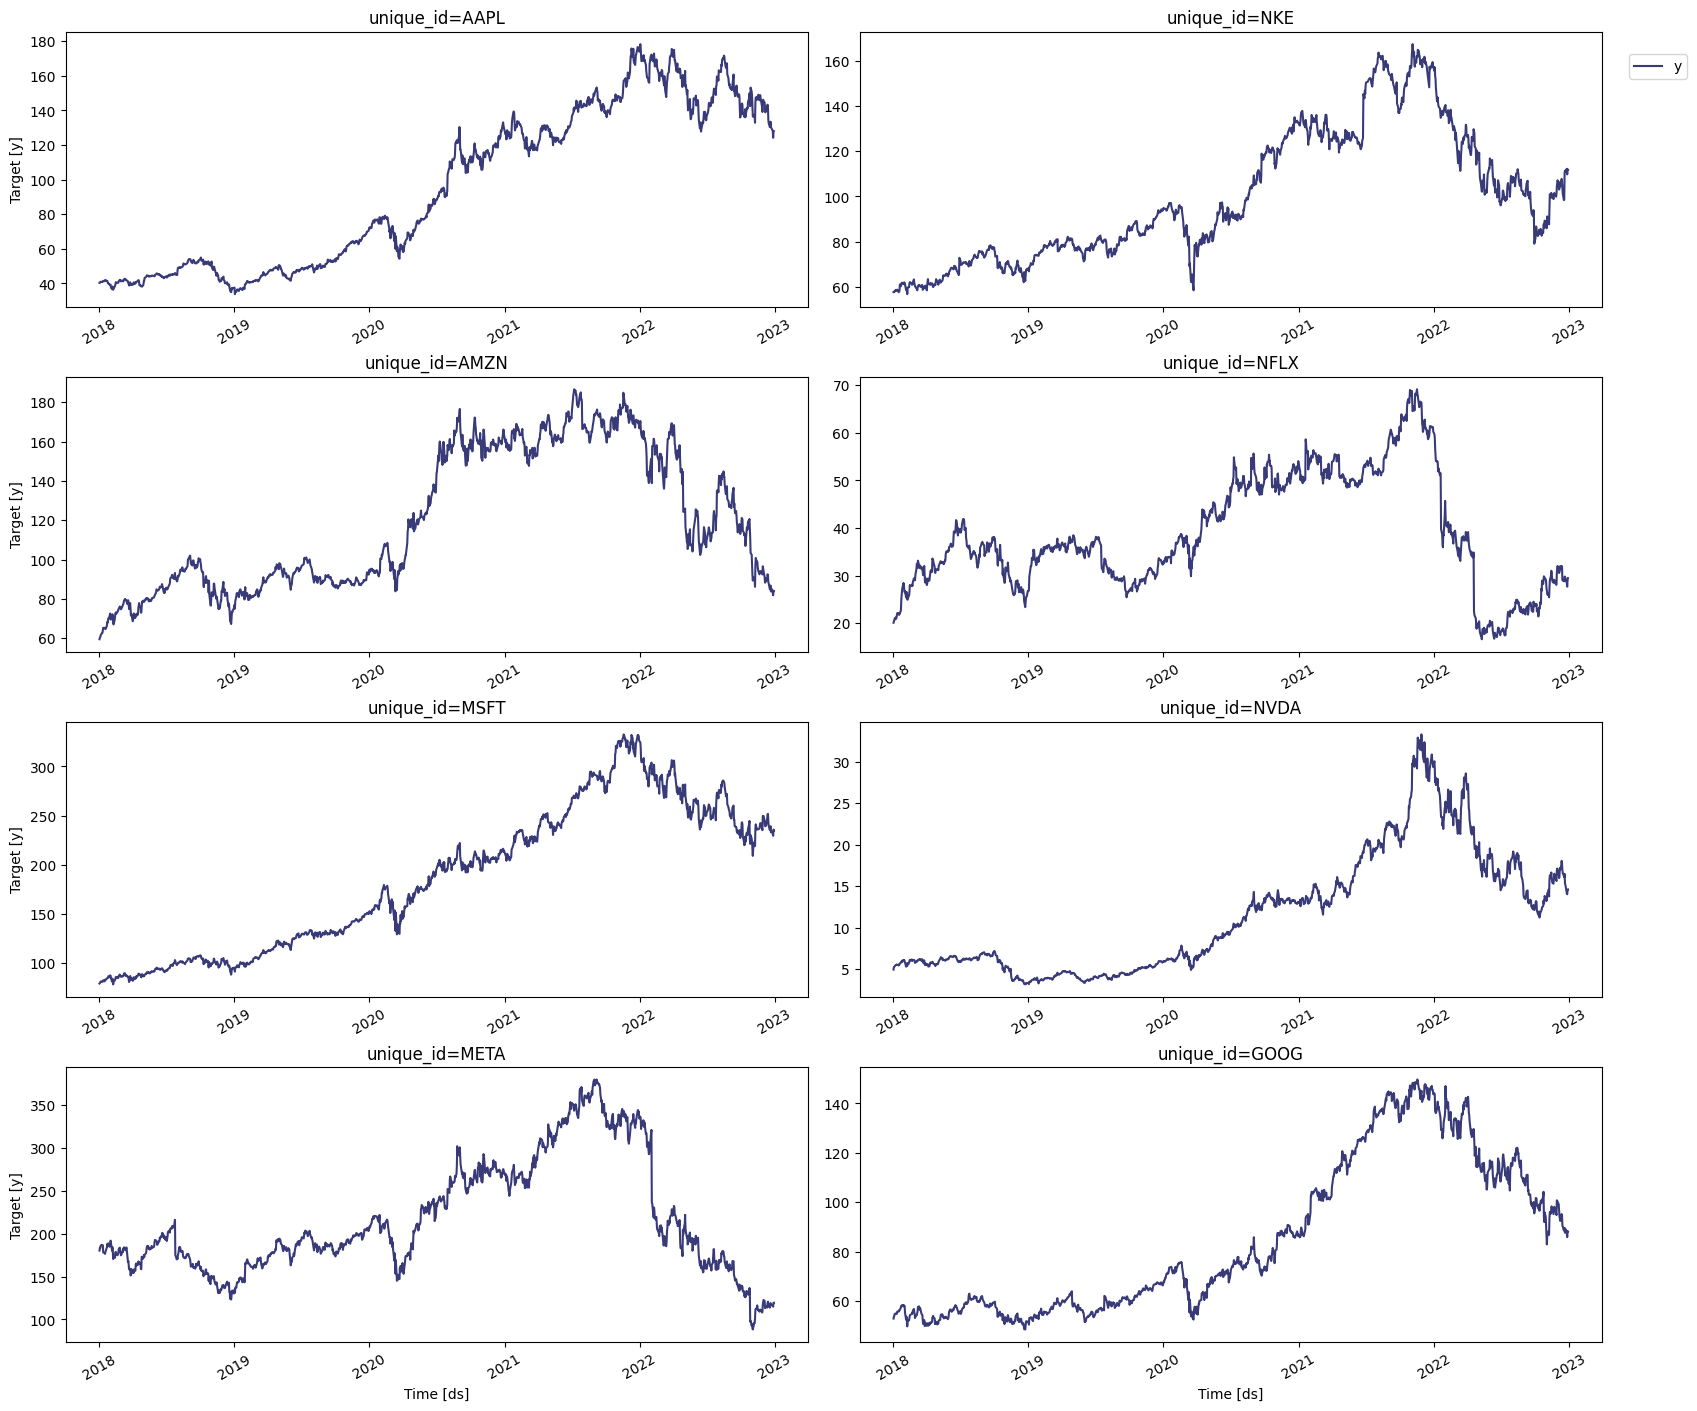

In [6]:
from statsforecast import StatsForecast
StatsForecast.plot(prices)

In [7]:
import numpy as np
prices['rt'] = prices['y'].div(prices.groupby('unique_id')['y'].shift(1))
prices['rt'] = np.log(prices['rt'])

returns = prices[['unique_id', 'ds', 'rt']]
returns = returns.rename(columns={'rt':'y'})
returns

,unique_id,ds,y
0,SPY,2018-01-02,NaN
1,SPY,2018-01-03,0.006305
2,SPY,2018-01-04,0.004206
3,SPY,2018-01-05,0.006642
4,SPY,2018-01-08,0.001827
...,...,...,...
12585,NFLX,2022-12-23,-0.009397
12586,NFLX,2022-12-27,-0.037284
12587,NFLX,2022-12-28,-0.025988
12588,NFLX,2022-12-29,0.050151


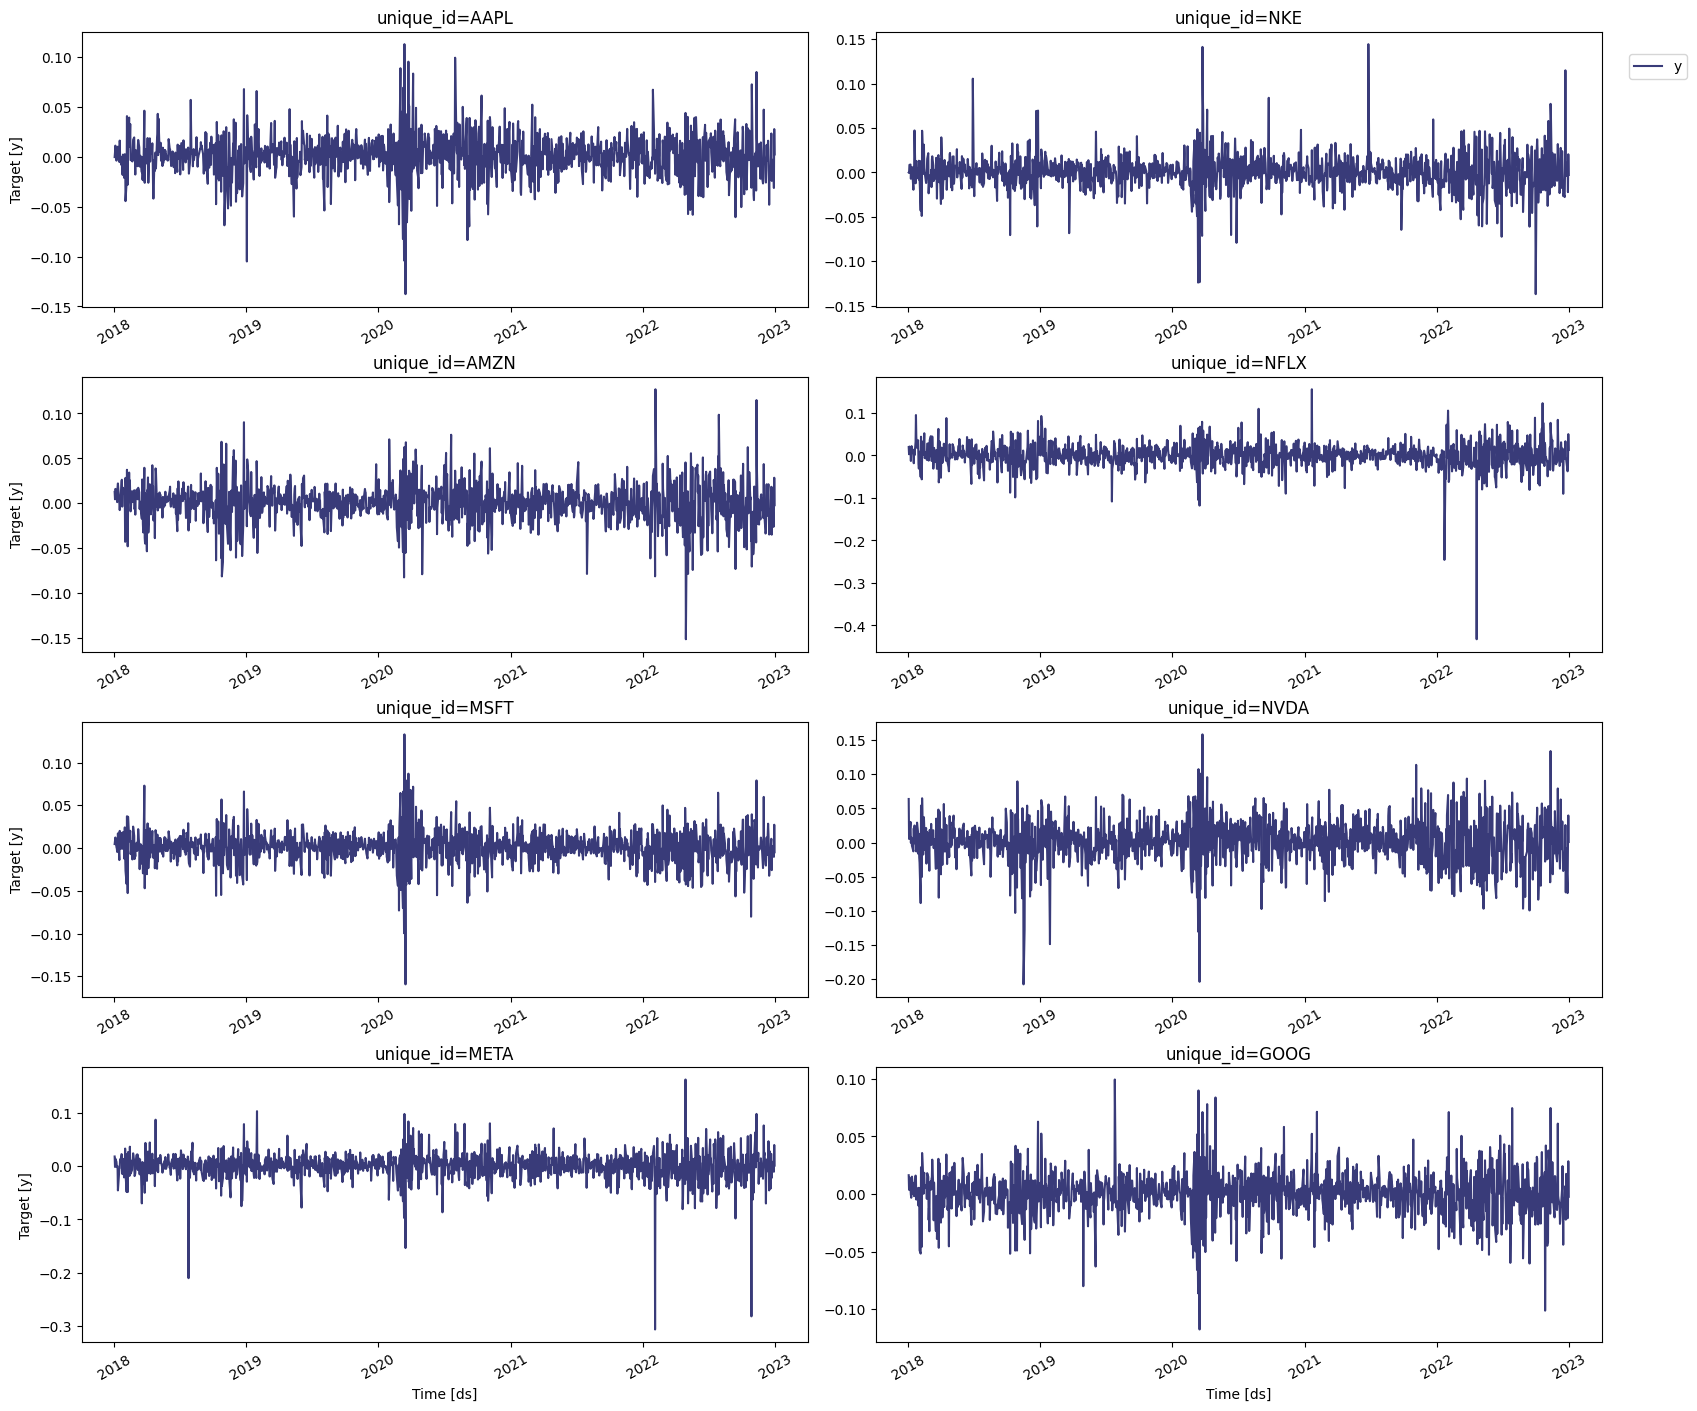

In [8]:
StatsForecast.plot(returns)

In [9]:
from statsforecast.models import (
    GARCH,
    ARCH,
    Naive
)

models = [ARCH(1),
          ARCH(2),
          GARCH(1,1),
          GARCH(1,2),
          GARCH(2,2),
          GARCH(2,1),
          Naive()
]

In [10]:
sf = StatsForecast(
    models = models,
    freq = 'D',
    n_jobs = -1
)

In [11]:
cv_df = sf.cross_validation(
    df = returns,
    h = 3,
    step_size = 3,
    n_windows = 4
  )

In [12]:
cv_df.rename(columns = {'y' : 'actual'}, inplace = True)
cv_df.head()

,unique_id,ds,cutoff,actual,ARCH(1),ARCH(2),"GARCH(1,1)","GARCH(1,2)","GARCH(2,2)","GARCH(2,1)",Naive
0,AAPL,2022-12-14,2022-12-13,-0.015658,0.030564,0.158725,0.100231,0.031850,0.027510,0.144168,0.006760
1,AAPL,2022-12-15,2022-12-13,-0.047987,-0.014314,-0.060318,-0.037749,-0.014094,-0.012205,-0.054296,0.006760
2,AAPL,2022-12-16,2022-12-13,-0.014686,-0.010413,-0.052143,-0.032591,-0.011226,-0.010470,-0.046878,0.006760
3,AAPL,2022-12-19,2022-12-16,-0.016038,0.152584,0.046799,0.074569,0.035231,0.044523,0.044545,-0.014686
4,AAPL,2022-12-20,2022-12-16,-0.000528,-0.057466,-0.016061,-0.028084,-0.014461,-0.016310,-0.015667,-0.014686


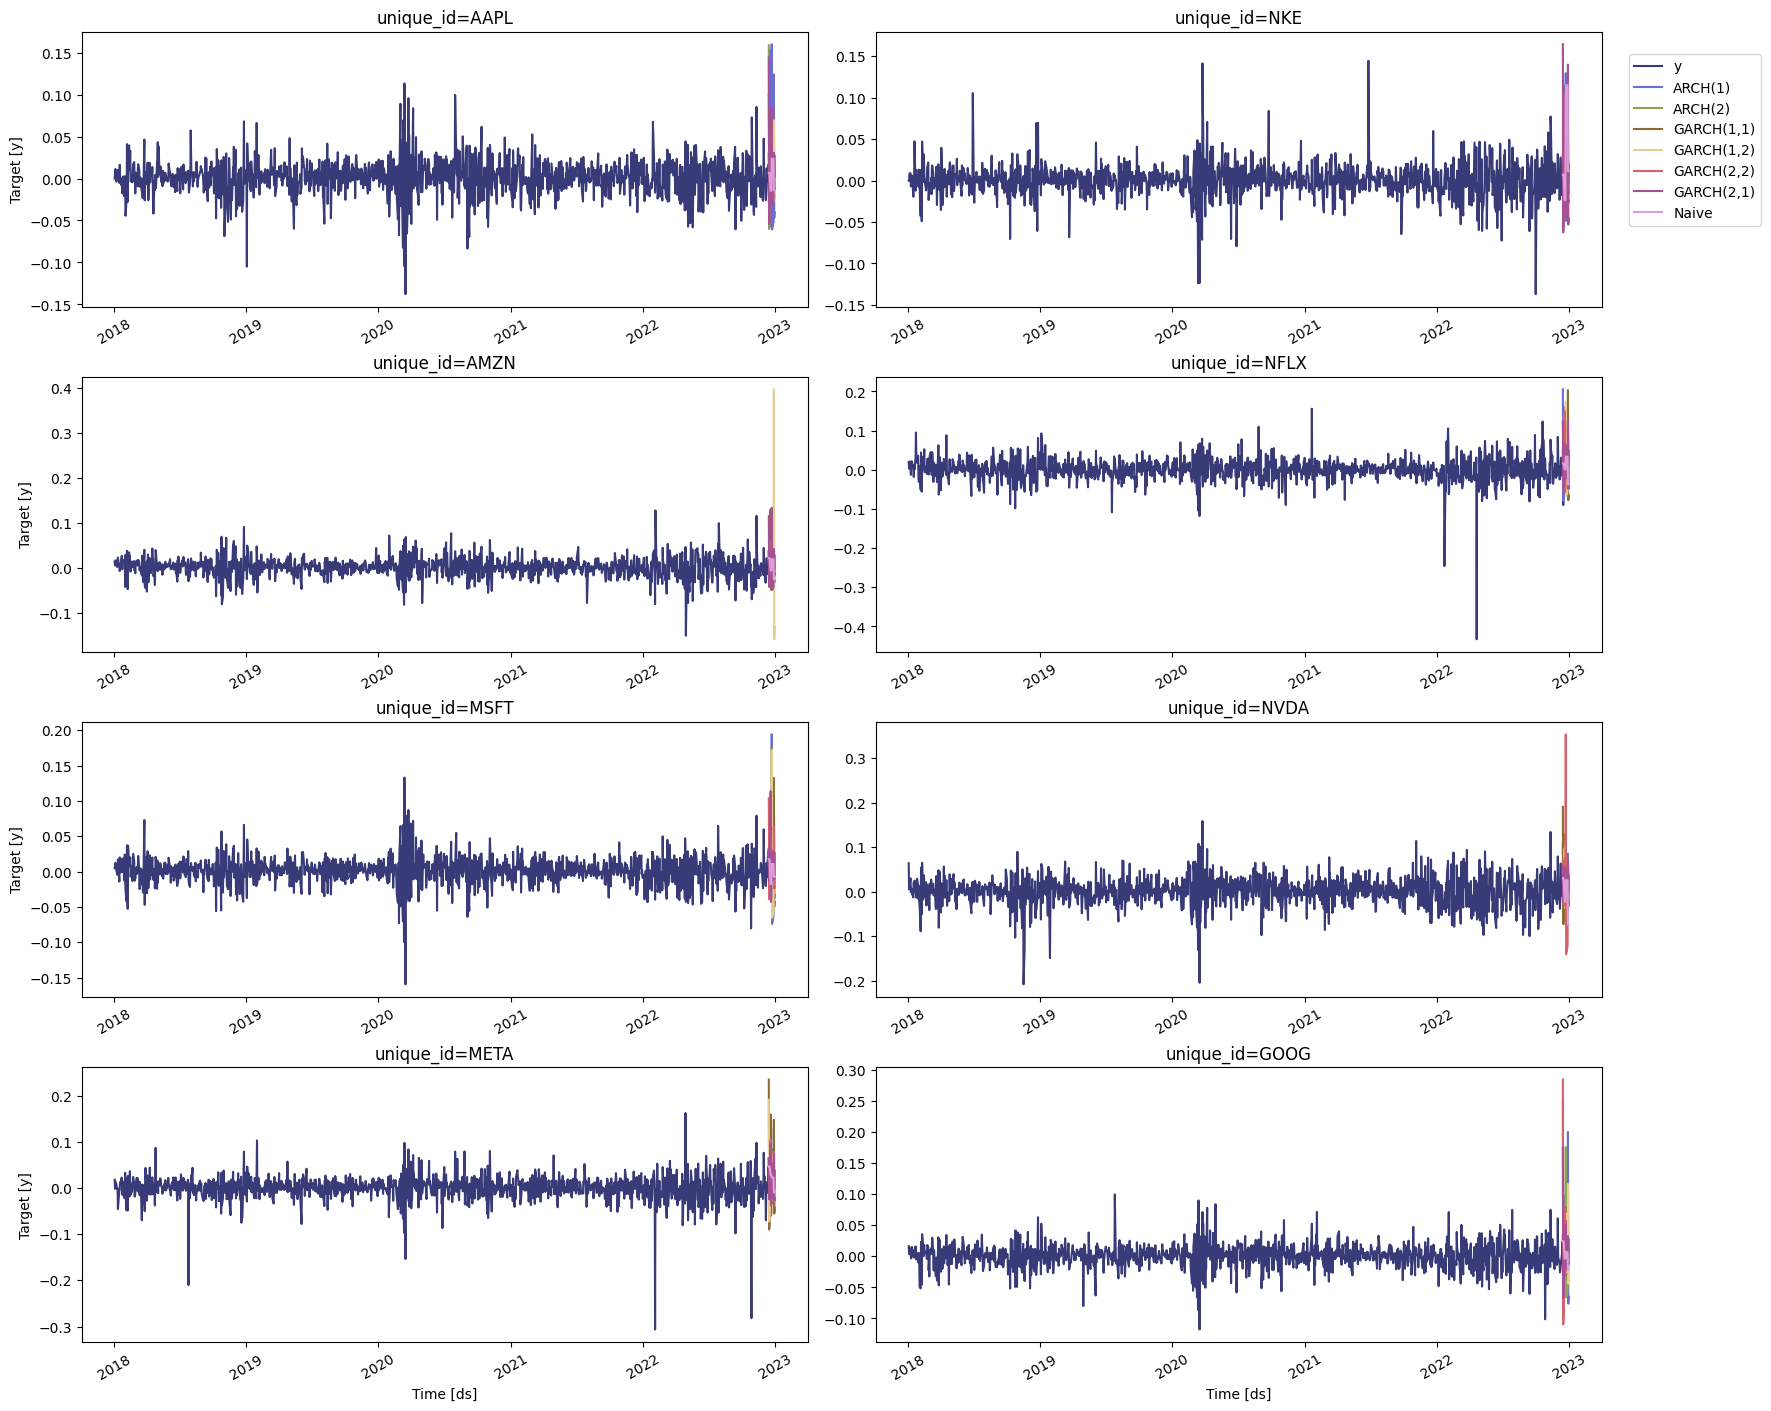

In [13]:
StatsForecast.plot(returns, cv_df.drop(['cutoff', 'actual'], axis=1))

In [14]:
from utilsforecast.losses import mae
models = cv_df.columns.drop(['unique_id', 'ds', 'cutoff', 'actual'])
mae_cv = mae(cv_df, models=models, target_col='actual').set_index('unique_id')
mae_cv

,ARCH(1),ARCH(2),"GARCH(1,1)","GARCH(1,2)","GARCH(2,2)","GARCH(2,1)",Naive
unique_id,,,,,,,
AAPL,0.077975,0.048595,0.041995,0.036358,0.032013,0.048181,0.028275
AMZN,0.054866,0.036183,0.049781,0.087932,0.034641,0.053740,0.030549
GOOG,0.064014,0.077783,0.034871,0.044885,0.069139,0.046962,0.025107
META,0.066190,0.054184,0.097462,0.062310,0.054716,0.055127,0.031542
MSFT,0.061414,0.048830,0.042613,0.045284,0.035957,0.036360,0.021308
NFLX,0.083756,0.049517,0.074574,0.070817,0.068258,0.063737,0.040425
NKE,0.049535,0.043981,0.052295,0.047702,0.041208,0.082685,0.053186
NVDA,0.054699,0.055230,0.075036,0.059946,0.086545,0.048740,0.060827
SPY,0.021160,0.045874,0.051711,0.029024,0.039172,0.024214,0.016481


In [15]:
mae_cv.idxmin(axis=1)

,0
unique_id,
AAPL,Naive
AMZN,Naive
GOOG,Naive
META,Naive
MSFT,Naive
NFLX,Naive
NKE,"GARCH(2,2)"
NVDA,"GARCH(2,1)"
SPY,Naive


In [16]:
levels = [80, 95] # confidence levels for the prediction intervals

forecasts = sf.forecast(df=returns, h=3, level=levels)
forecasts.head()

,unique_id,ds,ARCH(1),ARCH(1)-lo-95,ARCH(1)-lo-80,ARCH(1)-hi-80,ARCH(1)-hi-95,ARCH(2),ARCH(2)-lo-95,ARCH(2)-lo-80,...,"GARCH(2,1)","GARCH(2,1)-lo-95","GARCH(2,1)-lo-80","GARCH(2,1)-hi-80","GARCH(2,1)-hi-95",Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95
0,AAPL,2022-12-31,0.131845,0.118932,0.123402,0.140288,0.144757,0.099994,0.092567,0.095138,...,0.033592,0.032754,0.033044,0.034140,0.034430,0.002466,-0.037841,-0.059178,0.042773,0.064110
1,AAPL,2023-01-01,-0.049655,-0.062568,-0.058098,-0.041212,-0.036742,-0.037660,-0.045087,-0.042516,...,-0.013519,-0.014477,-0.014145,-0.012894,-0.012562,0.002466,-0.054536,-0.084711,0.059468,0.089643
2,AAPL,2023-01-02,-0.042871,-0.055783,-0.051314,-0.034427,-0.029958,-0.032514,-0.039942,-0.037371,...,-0.011435,-0.012353,-0.012035,-0.010834,-0.010516,0.002466,-0.067347,-0.104304,0.072279,0.109236
3,AMZN,2022-12-31,0.095811,0.088992,0.091352,0.100269,0.102630,0.166521,0.145923,0.153052,...,0.123382,0.112073,0.115988,0.130776,0.134690,-0.002141,-0.043633,-0.065598,0.039352,0.061317
4,AMZN,2023-01-01,-0.036194,-0.043055,-0.040680,-0.031708,-0.029333,-0.063325,-0.084326,-0.077057,...,-0.046468,-0.057776,-0.053862,-0.039074,-0.035160,-0.002141,-0.060820,-0.091883,0.056539,0.087602
